## **Random Forest Regression Implementation**

#### **1. Import Essential Libraries**

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

#### **2. Prepare the Dataset**

In [2]:
# Generate synthetic dataset
np.random.seed(42)
X = np.sort(5 * np.random.rand(100, 1), axis=0)
y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0]) # Target with noise

#### **3. Split the Data**

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### **4. Initialize and Train the Model**

In [4]:
# Instantiate the regressor
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model on the training subset
rf_regressor.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

#### **5. Predict & Evaluate**

In [5]:
# Predict continuous values
y_pred = rf_regressor.predict(X_test)

# Calculate Evaluation Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R² Score: {r2:.4f}")

Mean Squared Error (MSE): 0.0091
R² Score: 0.9810


#### **6. Hyperparameter Tuning with GridSearchCV**

In [7]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# 1. Load a realistic multi-feature dataset
data = fetch_california_housing(as_frame=True)
X, y = data.data, data.target

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Define the parameter grid to search over
param_grid = {
    'n_estimators': [100, 200, 300],      # Number of trees
    'max_depth': [5, 10, 15],     # Maximum depth of trees
    'min_samples_split': [1, 2, 5]      # Minimum samples required to split a node
}

# 3. Initialize the model and the grid search
rf = RandomForestRegressor(random_state=42, n_jobs=-1) # n_jobs=-1 speeds up training using all CPU cores
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)

# 4. Fit grid search to the data
grid_search.fit(X_train, y_train)

# 5. Extract the best model parameters
print("Best Hyperparameters found:")
print(grid_search.best_params_)

# Get the optimal model
best_rf_model = grid_search.best_estimator_

/home/rakesh/venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/rakesh/venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/rakesh/venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/rakesh/venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarnin

Best Hyperparameters found:
{'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 300}


#### **8. Feature Importance Evaluation**

In [8]:
import pandas as pd

# 1. Extract importances from the trained optimal model
importances = best_rf_model.feature_importances_

# 2. Match importances with feature names
feature_names = X.columns
rf_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# 3. Print the ranked features
print("\nFeature Importances (Ranked):")
print(rf_importances)



Feature Importances (Ranked):
MedInc        0.536992
AveOccup      0.138362
Latitude      0.087327
Longitude     0.087282
HouseAge      0.052753
AveRooms      0.042196
Population    0.027843
AveBedrms     0.027244
dtype: float64


#### **9. Visualizing Feature Importance**

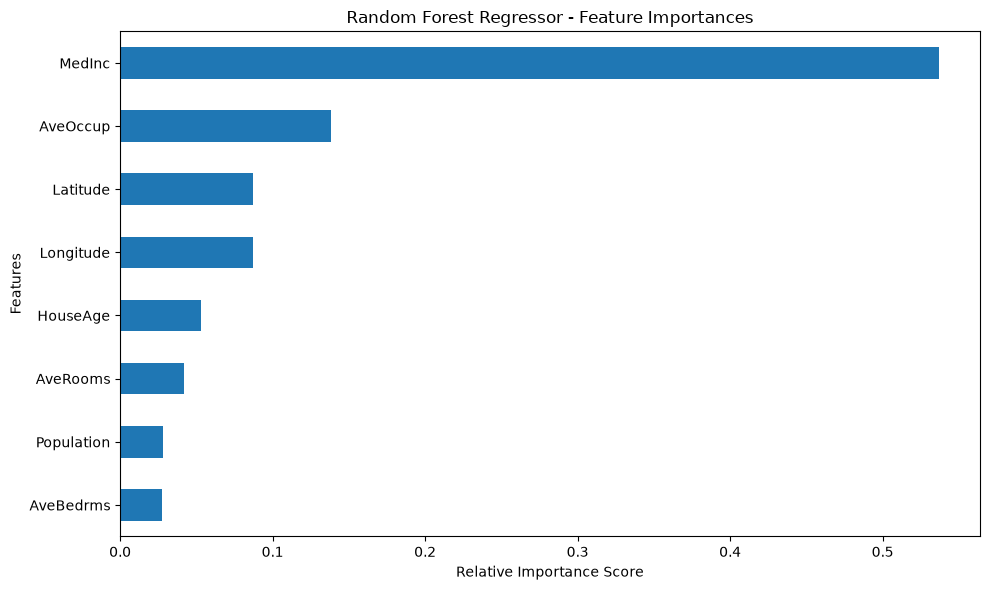

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
rf_importances.plot(kind='barh').invert_yaxis()  # Highest importance at the top
plt.title("Random Forest Regressor - Feature Importances")
plt.xlabel("Relative Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()
